In [2]:
import logging
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from ml_translate.data import get_dataloaders
from ml_translate.model import EncoderRNN, AttnDecoderRNN
from ml_translate.train import train
from ml_translate.eval import evaluate, evaluateRandomly, evaluate_bleu

# Configure logging to display in notebook
logging.basicConfig(level=logging.INFO, format="%(message)s")

Reading lines...
Read 135842 sentence pairs
Trimmed to 11445 sentence pairs
Counting words...
Counted words:
fra: 4601
eng: 2993
Split 11445 pairs into train=9156, val=1144, test=1145
0m 29s (remaining: 7m 14s) (epoch 5, 6%) train_loss=1.631 val_loss=1.484
0m 58s (remaining: 6m 49s) (epoch 10, 12%) train_loss=0.775 val_loss=1.063
1m 28s (remaining: 6m 21s) (epoch 15, 19%) train_loss=0.420 val_loss=0.930
1m 58s (remaining: 5m 55s) (epoch 20, 25%) train_loss=0.233 val_loss=0.895
Reducing learning rate to 0.000500
2m 28s (remaining: 5m 27s) (epoch 25, 31%) train_loss=0.133 val_loss=0.895
Reducing learning rate to 0.000250
Early stopping at epoch 29


Training stopped early! Best val loss: 0.8902


<Figure size 640x480 with 0 Axes>

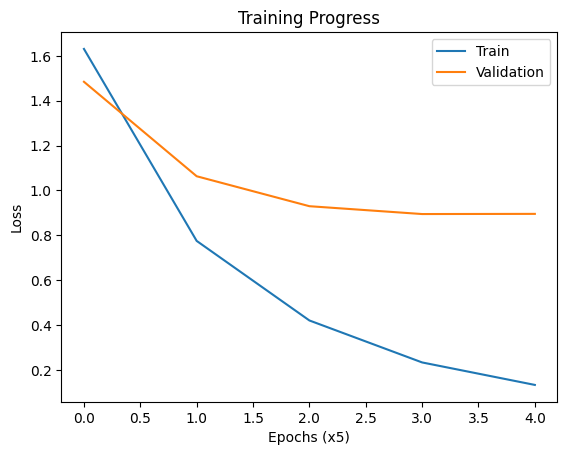

In [ ]:
hidden_size = 128
batch_size = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

(
    input_lang,
    output_lang,
    train_dataloader,
    val_dataloader,
    test_dataloader,
    test_pairs,
) = get_dataloaders(batch_size, device)

encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder = AttnDecoderRNN(hidden_size, output_lang.n_words, device=device).to(device)

result = train(
    train_dataloader,
    encoder,
    decoder,
    n_epochs=80,
    print_every=5,
    plot_every=5,
    val_dataloader=val_dataloader,
    early_stopping_patience=10,
    scheduler_patience=3,
    scheduler_factor=0.5,
    max_grad_norm=3.0,  # Clip gradients to prevent exploding gradients
)

if result.stopped_early:
    print(f"Training stopped early! Best val loss: {result.best_val_loss:.4f}")


def showPlot(train_losses, val_losses=None):
    plt.figure()
    fig, ax = plt.subplots()
    loc = ticker.MultipleLocator(base=0.2)
    ax.yaxis.set_major_locator(loc)
    plt.plot(train_losses, label="Train")
    if val_losses:
        plt.plot(val_losses, label="Validation")
        plt.legend()
    plt.xlabel("Epochs (x5)")
    plt.ylabel("Loss")
    plt.title("Training Progress")


showPlot(result.train_losses, result.val_losses)

In [ ]:
encoder.eval()
decoder.eval()

# Evaluate random samples qualitatively
evaluateRandomly(encoder, decoder, input_lang, output_lang, test_pairs, device)

# Compute BLEU score on test set
bleu = evaluate_bleu(encoder, decoder, test_pairs, input_lang, output_lang, device)
print(f"\nTest BLEU-4 score: {bleu:.4f}")

> je suis disponible
= i m available
< i am free <EOS>

> ils sont en train de se disputer
= they re arguing
< they re eating <EOS>

> tu es plus intelligente que moi
= you re smarter than me
< you re taller than i am <EOS>

> nous sommes vraiment maries
= we re really married
< we re really married <EOS>

> elle est occupee
= she s busy
< she is busy <EOS>

> je suis femme au foyer
= i am a housewife
< i m a housewife <EOS>

> je suis content que vous alliez a nouveau bien
= i m glad you re ok again
< i m glad you re ok again <EOS>

> il ecrit une longue lettre
= he s writing a long letter
< he is writing a letter very forward <EOS>

> je ne suis pas un professionnel
= i m not a professional
< i m not a drug addict <EOS>

> vous etes tres religieuses n est ce pas ?
= you re very religious aren t you ?
< you re very religious aren t you ? <EOS>

BLEU-4 score: 0.4852



Test BLEU-4 score: 0.4852


input = il n est pas aussi grand que son pere
output = he is not as tall as his father <EOS>


/var/folders/05/xrxbmd3x4sl_c5mmq5fx0ylc0000gn/T/ipykernel_47186/2607626902.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""] + input_sentence.split(" ") + ["<EOS>"], rotation=90)
/var/folders/05/xrxbmd3x4sl_c5mmq5fx0ylc0000gn/T/ipykernel_47186/2607626902.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + output_words)


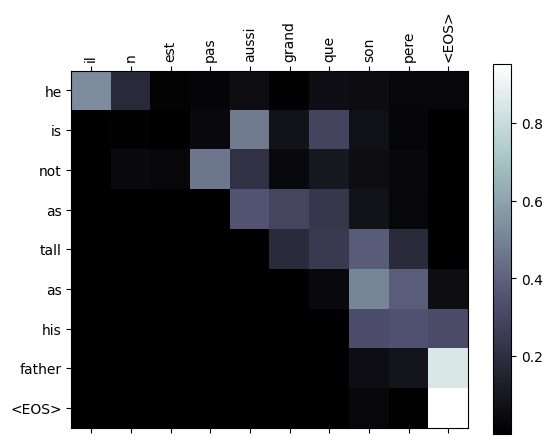

input = je suis trop fatigue pour conduire
output = i m too tired to drive for <EOS>


/var/folders/05/xrxbmd3x4sl_c5mmq5fx0ylc0000gn/T/ipykernel_47186/2607626902.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""] + input_sentence.split(" ") + ["<EOS>"], rotation=90)
/var/folders/05/xrxbmd3x4sl_c5mmq5fx0ylc0000gn/T/ipykernel_47186/2607626902.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + output_words)


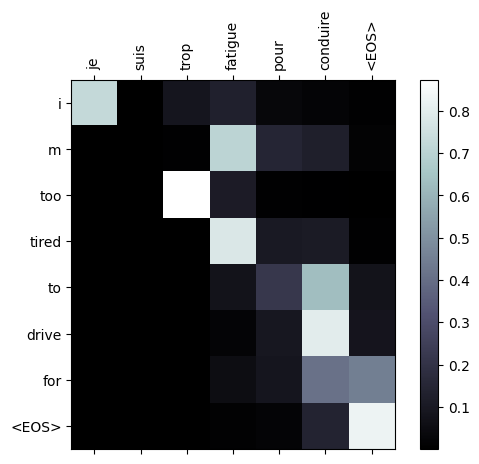

input = je suis desole si c est une question idiote
output = i m sorry if i love a serious offer <EOS>


/var/folders/05/xrxbmd3x4sl_c5mmq5fx0ylc0000gn/T/ipykernel_47186/2607626902.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""] + input_sentence.split(" ") + ["<EOS>"], rotation=90)
/var/folders/05/xrxbmd3x4sl_c5mmq5fx0ylc0000gn/T/ipykernel_47186/2607626902.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + output_words)


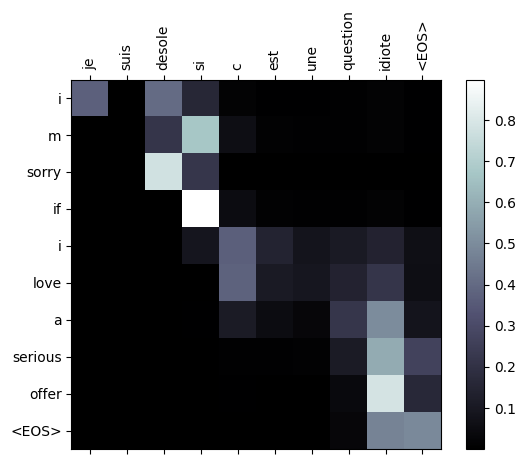

input = je suis reellement fiere de vous
output = i m really proud of you <EOS>


/var/folders/05/xrxbmd3x4sl_c5mmq5fx0ylc0000gn/T/ipykernel_47186/2607626902.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""] + input_sentence.split(" ") + ["<EOS>"], rotation=90)
/var/folders/05/xrxbmd3x4sl_c5mmq5fx0ylc0000gn/T/ipykernel_47186/2607626902.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + output_words)


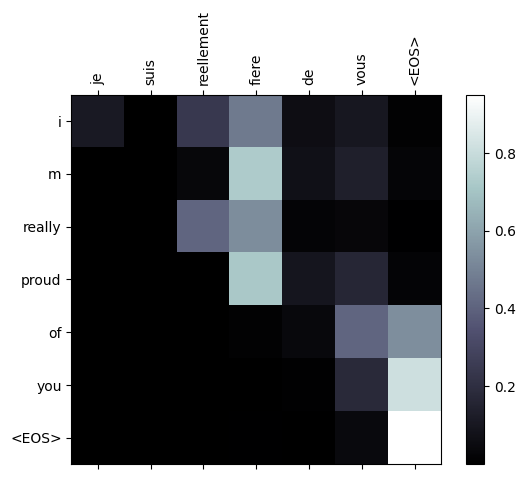

In [ ]:
def showAttention(input_sentence, output_words, attentions):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(attentions.cpu().numpy(), cmap="bone")
    fig.colorbar(cax)

    # Show label at every tick
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    # Set up axes
    ax.set_xticklabels([""] + input_sentence.split(" ") + ["<EOS>"], rotation=90)
    ax.set_yticklabels([""] + output_words)

    plt.show()


def evaluateAndShowAttention(input_sentence):
    output_words, attentions = evaluate(
        encoder, decoder, input_sentence, input_lang, output_lang, device
    )
    print("input =", input_sentence)
    print("output =", " ".join(output_words))
    showAttention(input_sentence, output_words, attentions[0, : len(output_words), :])


evaluateAndShowAttention("il n est pas aussi grand que son pere")
evaluateAndShowAttention("je suis trop fatigue pour conduire")
evaluateAndShowAttention("je suis desole si c est une question idiote")
evaluateAndShowAttention("je suis reellement fiere de vous")